# Running a baroclinic instability test case

First we set up the mpi environment:

In [1]:
import ipyparallel as ipp
ntiles = 6
layout = (1, 1)

num_ranks = ntiles * layout[0] * layout[1]
cluster = ipp.Cluster(engines="mpi", n=num_ranks).start_and_connect_sync()

# start executing cells on the workers in parallel from here on
%autopx

Starting 6 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>
100%|██████████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.05engine/s]
%autopx enabled


[0:execute]
---------------------------------------------------------------------------
IndexError                                Traceback (most recent call last)
Cell In[9], line 13
     11 fig = plt.figure(figsize=(12, 6))
     12 ax = fig.add_subplot(111, projection=ccrs.Robinson())
---> 13 f1 = pcolormesh_cube(
     14     grid_lat.data * 180./np.pi,
     15     grid_lon.data * 180./np.pi + rotation,
     16     temperature.data[:, :, :, -2],
     17     cmap="viridis",
     18 )
     19 plt.colorbar(f1, label="Temperature (K)")
     20 ax.set_title(f"Temperature ({nx} x {nx} points per tile)")

File /fv3net/external/fv3viz/fv3viz/_plot_cube.py:291, in pcolormesh_cube(lat, lon, array, ax, **kwargs)
    264 """Plots tiled cubed sphere. This function applies nan to gridcells which cross
    265 the antimeridian, and then iteratively plots rectangles of array which avoid nan
    266 gridcells. This is done to avoid artifacts when plotting gridlines with the
   (...)    288         ma

Double-check the MPI setup:

In [2]:
from mpi4py import MPI

mpi_comm = MPI.COMM_WORLD
mpi_size = mpi_comm.Get_size()
mpi_rank = mpi_comm.Get_rank()

print(f"I am MPI-rank {mpi_rank} of a total of {mpi_size}")

[stdout:0] I am MPI-rank 0 of a total of 6


[stdout:2] I am MPI-rank 2 of a total of 6


[stdout:4] I am MPI-rank 4 of a total of 6


[stdout:1] I am MPI-rank 1 of a total of 6


[stdout:3] I am MPI-rank 3 of a total of 6


[stdout:5] I am MPI-rank 5 of a total of 6


Next we set up the model driver using the yaml config file:

In [3]:
%%time

from pace import Driver, DriverConfig
import yaml

config_file = "baroclinic_c20.yaml"

with open(config_file, "r") as f:
    driver_config = DriverConfig.from_dict(yaml.safe_load(f))
driver = Driver(config=driver_config)

[output:0]

[output:3]

[output:5]

[output:2]

[output:1]

...

[stderr:0] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/ndsl/initialization/allocator.py:262: UserWarning: Found inconsistency with number of halo points in Quantity:2 vs 3
  return temp_quantity.halo_spec(n_halo)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:

[stderr:5] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/ndsl/grid/gnomonic.py:681: RuntimeWarning: invalid value encountered in divide
  np.sum(p * q, axis=-1) / np.sqrt(np.sum(p**2, axis=-1) * np.sum(q**2, axis=-1))
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/ndsl/initialization/allocator.py:262: Use

[stderr:4] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/ndsl/initialization/allocator.py:262: UserWarning: Found inconsistency with number of halo points in Quantity:2 vs 3
  return temp_quantity.halo_spec(n_halo)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:

[stderr:2] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/ndsl/grid/gnomonic.py:681: RuntimeWarning: invalid value encountered in divide
  np.sum(p * q, axis=-1) / np.sqrt(np.sum(p**2, axis=-1) * np.sum(q**2, axis=-1))
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/ndsl/initialization/allocator.py:262: Use

%px: 100%|██████████████████████████████████████████████████████████████████████| 6/6 [04:29<00:00, 44.99s/tasks]


In [4]:
if mpi_rank == 0:
    print(driver.state.grid_data.lon_agrid.shape)

[stdout:0] (27, 27)


We can inspect the initial model state:

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from cartopy import crs as ccrs
from fv3viz import pcolormesh_cube
from ndsl import CubedSphereCommunicator

communicator = CubedSphereCommunicator.from_layout(
    comm=driver.comm,
    layout=driver.config.layout,
)
u_wind = communicator.gather(driver.state.dycore_state.u)
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
grid_lon = communicator.gather(driver.state.grid_data.lon)
grid_lat = communicator.gather(driver.state.grid_data.lat)
a_lon = communicator.gather(driver.state.grid_data.lon_agrid)
a_lat = communicator.gather(driver.state.grid_data.lat_agrid)

[output:0]

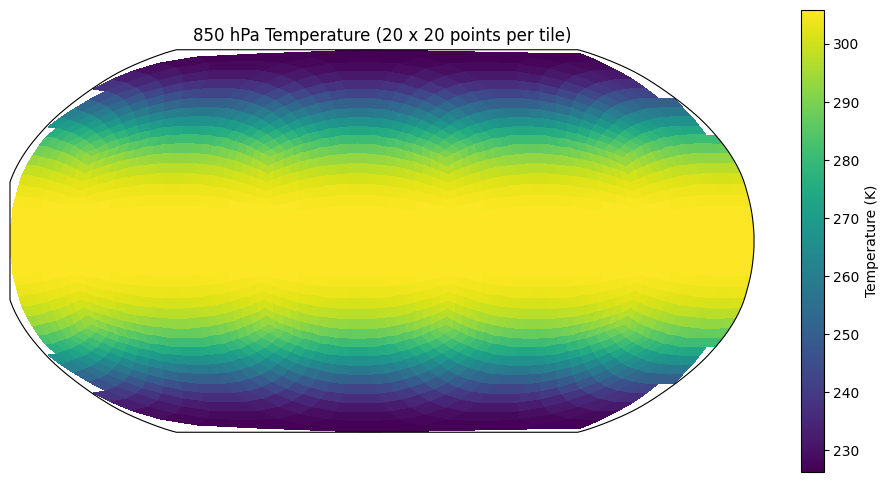

In [6]:
if mpi_rank == 0:
    u_mean = 0.5 * (u_wind.data[:,:,:-1, :] + u_wind.data[:,:, 1:, :])
    
    nx = temperature.shape[1]
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi,
        temperature.data[:, :, :, -2],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"850 hPa Temperature ({nx} x {nx} points per tile)")
    
#     fig = plt.figure(figsize=(12, 6))
#     ax = fig.add_subplot(111, projection=ccrs.Robinson())
#     f1 = pcolormesh_cube(
#         grid_lat.data * 180./np.pi,
#         grid_lon.data * 180./np.pi,
#         surface_pressure.data[:, :, :]/100.,
#         cmap="viridis",
#     )
#     plt.colorbar(f1, label="Surface Pressure (hPa)")
#     ax.set_title(f"Surface Pressure ({nx} x {nx} points per tile)")
    
    
#     fig = plt.figure(figsize=(12, 6))
#     ax = fig.add_subplot(111, projection=ccrs.Robinson())
#     f1 = pcolormesh_cube(
#         grid_lat.data * 180./np.pi,
#         grid_lon.data * 180./np.pi,
#         u_mean[:,:,:,65],
#         cmap="bwr",
#     )
#     plt.colorbar(f1, label="U wind (m/s)")
#     ax.set_title(f"U Wind ({nx} x {nx} points per tile)")

And then we can run the model:

In [7]:
%%time
try:
    driver.step_all()
finally:
    driver.cleanup()

[stdout:0] 2026-02-11 02:57:15|INFO|rank 0|ndsl.logging:integrating driver forward in time
2026-02-11 02:57:15|INFO|rank 0|ndsl.logging:FV Setup
2026-02-11 02:57:15|INFO|rank 0|ndsl.logging:Adjust pt
2026-02-11 02:57:15|WARNING|rank 0|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis x: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 0|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis y: 20 < 26.
2026-02-11 02:57:15|INFO|rank 0|ndsl.logging:DynCore
2026-02-11 02:57:15|WARNING|rank 0|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis x_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 0|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis y: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 0|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis x: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 0|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis y_interface: 21 < 26.
2

[stdout:1] 2026-02-11 02:57:15|INFO|rank 1|ndsl.logging:integrating driver forward in time
2026-02-11 02:57:15|WARNING|rank 1|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis x: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 1|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis y: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 1|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis x_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 1|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis y: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 1|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis x: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 1|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis y_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 1|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis x_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 

[stdout:5] 2026-02-11 02:57:15|INFO|rank 5|ndsl.logging:integrating driver forward in time
2026-02-11 02:57:15|WARNING|rank 5|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis x: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 5|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis y: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 5|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis x_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 5|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis y: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 5|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis x: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 5|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis y_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 5|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis x_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 

[stdout:2] 2026-02-11 02:57:15|INFO|rank 2|ndsl.logging:integrating driver forward in time
2026-02-11 02:57:15|WARNING|rank 2|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis x: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 2|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis y: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 2|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis x_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 2|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis y: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 2|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis x: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 2|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis y_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 2|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis x_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 

[stdout:4] 2026-02-11 02:57:15|INFO|rank 4|ndsl.logging:integrating driver forward in time
2026-02-11 02:57:15|WARNING|rank 4|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis x: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 4|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis y: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 4|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis x_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 4|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis y: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 4|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis x: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 4|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis y_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 4|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis x_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 

[stdout:3] 2026-02-11 02:57:15|INFO|rank 3|ndsl.logging:integrating driver forward in time
2026-02-11 02:57:15|WARNING|rank 3|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis x: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 3|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis y: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 3|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis x_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 3|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis y: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 3|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis x: 20 < 26.
2026-02-11 02:57:15|WARNING|rank 3|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis y_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 3|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis x_interface: 21 < 26.
2026-02-11 02:57:15|WARNING|rank 

%px: 100%|██████████████████████████████████████████████████████████████████████| 6/6 [00:29<00:00,  4.84s/tasks]


Now let's investigate the model state

In [8]:
u_wind = communicator.gather(driver.state.dycore_state.u)
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
grid_lon = communicator.gather(driver.state.grid_data.lon)
grid_lat = communicator.gather(driver.state.grid_data.lat)
a_lon = communicator.gather(driver.state.grid_data.lon_agrid)
a_lat = communicator.gather(driver.state.grid_data.lat_agrid)
qvap = communicator.gather(driver.state.dycore_state.qvapor)
qcld = communicator.gather(driver.state.dycore_state.qcld)
qrain = communicator.gather(driver.state.dycore_state.qrain)

In [9]:
if mpi_rank == 0:
    print(driver.state.radiation_state.prsi.field[5,3,:])
#     print(driver.state.physics_state.tsfc.field[:])
    print(driver.physics._prescribe_sst)

[stdout:0] [ nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan
  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan
  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan
  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan
  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan
  nan  nan  nan  nan  nan  nan  nan  nan  nan 300.]
True


[stderr:0] /fv3net/external/fv3viz/fv3viz/_plot_cube.py:308: RuntimeWarning: All-NaN slice encountered
  kwargs["vmin"] = kwargs.get("vmin", np.nanmin(array))
/fv3net/external/fv3viz/fv3viz/_plot_cube.py:309: RuntimeWarning: All-NaN slice encountered
  kwargs["vmax"] = kwargs.get("vmax", np.nanmax(array))


[output:0]

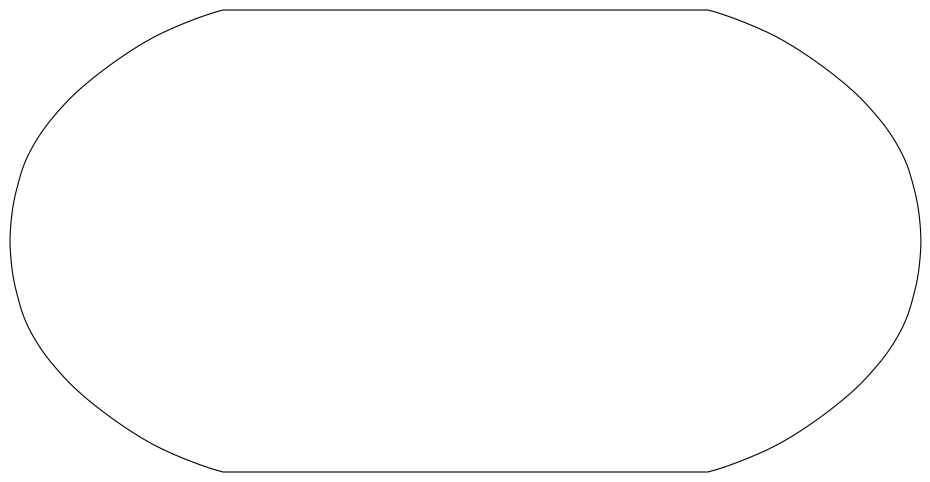

AlreadyDisplayedError: 1 errors

In [10]:
if mpi_rank == 0:
    rotation = -120.
    nx = temperature.shape[1]
    nz = temperature.shape[3]
    
    u_mean = 0.5 * (u_wind.data[:,:,:-1, :] + u_wind.data[:,:, 1:, :])
    column_qvap = np.sum(qvap, axis=3)/nz
    column_qcld = np.sum(qcld, axis=3)/nz
    column_qrain = np.sum(qrain, axis=3)/nz
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        temperature.data[:, :, :, -2],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"Temperature ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        surface_pressure.data[:, :, :]/100.,
        cmap="viridis",
    )
    plt.colorbar(f1, label="Surface Pressure (hPa)")
    ax.set_title(f"Surface Pressure ({nx} x {nx} points per tile)")
    
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qvap,
        cmap="viridis",
    )
    plt.colorbar(f1, label="water vapor mixing ratio")
    ax.set_title(f"Column-Integrated Water Vapor Mixing Ratio ({nx} x {nx} points per tile)")
    

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qrain,
        cmap="viridis",
    )
    plt.colorbar(f1, label="rain mixing ratio")
    ax.set_title(f"Column-Integrated Rain Mixing Ratio ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qcld,
        cmap="viridis",
    )
    plt.colorbar(f1, label="cloud mixing ratio")
    ax.set_title(f"Column-Integrated Cloud Mixing Ratio ({nx} x {nx} points per tile)")